# Proyek Analisis Data: [Input Nama Dataset]
- **Nama:** Bike Sharing Dataset
- **Email:** fhoodhyps@gmail.com
- **ID Dicoding:** diahapsss / cdcc156d6x1244

## Menentukan Pertanyaan Bisnis

- Bagaimana pengaruh kondisi cuaca terhadap jumlah penyewaan sepeda pada sistem bike sharing selama tahun 2011–2012?

- Bagaimana perbedaan jumlah penyewaan sepeda antara hari kerja dan hari libur pada sistem bike sharing selama periode 2011–2012?

- Pada jam berapa aktivitas penyewaan sepeda paling tinggi dalam satu hari berdasarkan data tahun 2011–2012?

## Import Semua Packages/Library yang Digunakan

In [1]:
# Import library yang dibutuhkan
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Data Wrangling

### Gathering Data

In [2]:
# Memuat dataset
day_df = pd.read_csv("day.csv")
hour_df = pd.read_csv("hour.csv")

In [13]:
day_df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [14]:
hour_df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


**Insight:**
- Pada analisis ini dataset yang digunakan terdiri dari dua file: day.csv yang berisi data penyewaan sepeda per hari dan hour.csv yang berisi data penyewaan sepeda per jam.
- Kedua dataset dimuat menggunakan library pandas untuk proses analisis dan eksplorasi data pada tahap berikutnya.

### Assessing Data

#### Menilai Table Day

In [3]:
# Melihat informasi dataset day
day_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB


In [5]:
# Mengecek missing value dataset day
day_df.isna().sum()

,0
instant,0
dteday,0
season,0
yr,0
mnth,0
holiday,0
weekday,0
workingday,0
weathersit,0
temp,0


In [7]:
# Mengecek duplikasi dataset day
print("Jumlah duplikasi data day:", day_df.duplicated().sum())

Jumlah duplikasi data day: 0


#### Menilai Table Hour

In [4]:
# Melihat informasi dataset hour
hour_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB


In [6]:
# Mengecek missing value dataset hour
hour_df.isna().sum()

,0
instant,0
dteday,0
season,0
yr,0
mnth,0
hr,0
holiday,0
weekday,0
workingday,0
weathersit,0


In [9]:
# Mengecek duplikasi dataset hour
print("Jumlah duplikasi data hour:", hour_df.duplicated().sum())

Jumlah duplikasi data hour: 0


**Insight:**
- Dataset day.csv memiliki 731 baris data dan 16 kolom, sedangkan dataset hour.csv memiliki 17.379 baris data dan 17 kolom.

- Berdasarkan pemeriksaan menggunakan .info() dan .isna().sum(), kedua dataset tidak memiliki missing value.

- Pemeriksaan duplikasi data menunjukkan bahwa tidak terdapat data duplikat pada kedua dataset.

- Namun, kolom dteday masih bertipe object, sehingga perlu dikonversi menjadi tipe datetime agar mempermudah analisis berbasis waktu pada tahap selanjutnya.

### Cleaning Data

In [15]:
# Mengubah tipe data kolom dteday menjadi datetime
day_df['dteday'] = pd.to_datetime(day_df['dteday'])
hour_df['dteday'] = pd.to_datetime(hour_df['dteday'])

In [16]:
# Menghapus kolom instant karena hanya merupakan index
day_df.drop(columns=['instant'], inplace=True)
hour_df.drop(columns=['instant'], inplace=True)

In [17]:
# Melihat 5 baris pertama table day
day_df.head(5)

,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [18]:
# Melihat 5 baris pertama table hour
hour_df.head(5)

,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


**Insight:**
- Kolom dteday pada kedua dataset dikonversi dari tipe data object menjadi datetime agar dapat digunakan untuk analisis berbasis waktu.

- Kolom instant dihapus karena hanya berfungsi sebagai indeks data dan tidak memberikan informasi yang relevan untuk proses analisis.

## Exploratory Data Analysis (EDA)

### Explore day_df

In [20]:
day_df.sample(5)

,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
629,2012-09-21,3,1,9,0,5,1,1,0.599167,0.571971,0.668750,0.154229,1250,6917,8167
146,2011-05-27,2,0,5,0,5,1,1,0.681667,0.637008,0.653750,0.240679,871,3808,4679
185,2011-07-05,3,0,7,0,2,1,1,0.746667,0.696338,0.590417,0.126258,1031,3634,4665
592,2012-08-15,3,1,8,0,3,1,1,0.706667,0.654037,0.619583,0.169771,1198,6149,7347
82,2011-03-24,2,0,3,0,4,1,2,0.285000,0.270833,0.805833,0.243787,166,1699,1865


In [8]:
# Melihat statistika deskriptif dataset day
day_df.describe()

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


In [22]:
# Pola Penyewaan Berdasarkan Bulan
day_df.groupby(by="mnth")["cnt"].mean().sort_values(ascending=False)

,cnt
mnth,
6,5772.366667
9,5766.516667
8,5664.419355
7,5563.677419
5,5349.774194
10,5199.225806
4,4484.900000
11,4247.183333
3,3692.258065


In [24]:
# Rata-rata penyewaan sepeda berdasarkan kondisi cuaca
day_df.groupby(by="weathersit")["cnt"].mean().sort_values(ascending=False)

,cnt
weathersit,
1,4876.786177
2,4035.862348
3,1803.285714


In [25]:
# Rata-rata penyewaan sepeda berdasarkan hari kerja
day_df.groupby(by="workingday")["cnt"].mean().sort_values(ascending=False)

,cnt
workingday,
1,4584.820000
0,4330.168831


**Insight:**
- Rata-rata jumlah penyewaan sepeda menunjukkan variasi pada setiap bulan. Berdasarkan hasil analisis, bulan September, Juni, dan Agustus memiliki rata-rata jumlah penyewaan sepeda yang paling tinggi dibandingkan bulan lainnya. Hal ini menunjukkan bahwa aktivitas penyewaan sepeda cenderung meningkat pada pertengahan hingga akhir tahun.

- Kondisi cuaca juga mempengaruhi jumlah penyewaan sepeda. Penyewaan sepeda paling tinggi terjadi pada kondisi cuaca cerah (weathersit = 1) dengan rata-rata sekitar 4876 penyewaan, sedangkan jumlah penyewaan menurun pada kondisi cuaca yang lebih buruk.

- Perbandingan antara hari kerja dan hari libur menunjukkan bahwa rata-rata penyewaan sepeda sedikit lebih tinggi pada hari kerja dibandingkan hari non-kerja, yang menunjukkan bahwa sepeda kemungkinan banyak digunakan untuk aktivitas mobilitas seperti pergi bekerja atau sekolah.

### Explore hour_df

In [21]:
hour_df.sample(5)

,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
7435,2011-11-11,4,0,11,10,1,5,0,1,0.32,0.2727,0.42,0.5522,38,162,200
17220,2012-12-25,1,1,12,9,1,2,0,2,0.24,0.2576,0.87,0.0000,7,21,28
7488,2011-11-13,4,0,11,15,0,0,0,2,0.50,0.4848,0.42,0.3284,89,221,310
6767,2011-10-14,4,0,10,13,0,5,1,1,0.56,0.5303,0.73,0.3582,18,114,132
15205,2012-09-30,4,1,9,18,0,0,0,1,0.52,0.5000,0.59,0.4478,91,310,401


In [10]:
# Melihat statistika deskriptif dataset hour
hour_df.describe()

,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
std,5017.0295,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599
min,1.0000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


In [23]:
# Pola Jam Sibuk Berdasarkan Dataset Hour
hour_df.groupby(by="hr")["cnt"].mean().sort_values(ascending=False)

,cnt
hr,
17,461.452055
18,425.510989
8,359.011004
16,311.983562
19,311.523352
13,253.661180
12,253.315934
15,251.233196
14,240.949246


In [26]:
# Rata-rata penyewaan sepeda berdasarkan hari kerja
hour_df.groupby(by="workingday")["cnt"].mean().sort_values(ascending=False)

,cnt
workingday,
1,193.207754
0,181.405332


**Insight:**
- Analisis pola penyewaan berdasarkan jam menunjukkan adanya jam sibuk (peak hour) pada aktivitas penyewaan sepeda. Jam 17.00 dan 18.00 memiliki rata-rata penyewaan tertinggi, diikuti oleh jam 08.00, yang kemungkinan berkaitan dengan waktu pulang dan berangkat kerja.

- Pola ini menunjukkan bahwa sepeda banyak digunakan sebagai sarana transportasi harian, terutama pada waktu aktivitas mobilitas masyarakat meningkat.

- Selain itu, rata-rata penyewaan sepeda juga sedikit lebih tinggi pada hari kerja dibandingkan hari libur, yang kembali menunjukkan bahwa sepeda sering digunakan untuk kebutuhan transportasi rutin.

### Explore day_df & hour_df

In [27]:
day_hour_df = pd.merge(
    left=hour_df,
    right=day_df,
    how="left",
    on="dteday",
    suffixes=("_hour","_day")
)

day_hour_df.head()

,dteday,season_hour,yr_hour,mnth_hour,hr,holiday_hour,weekday_hour,workingday_hour,weathersit_hour,temp_hour,...,weekday_day,workingday_day,weathersit_day,temp_day,atemp_day,hum_day,windspeed_day,casual_day,registered_day,cnt_day
0,2011-01-01,1,0,1,0,0,6,0,1,0.24,...,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2011-01-01,1,0,1,1,0,6,0,1,0.22,...,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
2,2011-01-01,1,0,1,2,0,6,0,1,0.22,...,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
3,2011-01-01,1,0,1,3,0,6,0,1,0.24,...,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
4,2011-01-01,1,0,1,4,0,6,0,1,0.24,...,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985


In [31]:
day_hour_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 30 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   dteday           17379 non-null  datetime64[ns]
 1   season_hour      17379 non-null  int64         
 2   yr_hour          17379 non-null  int64         
 3   mnth_hour        17379 non-null  int64         
 4   hr               17379 non-null  int64         
 5   holiday_hour     17379 non-null  int64         
 6   weekday_hour     17379 non-null  int64         
 7   workingday_hour  17379 non-null  int64         
 8   weathersit_hour  17379 non-null  int64         
 9   temp_hour        17379 non-null  float64       
 10  atemp_hour       17379 non-null  float64       
 11  hum_hour         17379 non-null  float64       
 12  windspeed_hour   17379 non-null  float64       
 13  casual_hour      17379 non-null  int64         
 14  registered_hour  17379 non-null  int64

In [28]:
# Melihat Pola Penyewaan Berdasarkan Jam
day_hour_df.groupby(by="hr")["cnt_hour"].mean().sort_values(ascending=False)

,cnt_hour
hr,
17,461.452055
18,425.510989
8,359.011004
16,311.983562
19,311.523352
13,253.661180
12,253.315934
15,251.233196
14,240.949246


In [29]:
# Melihat Pola Berdasarkan Musim
day_hour_df.groupby(by="season_day")["cnt_hour"].mean().sort_values(ascending=False)

,cnt_hour
season_day,
3,236.016237
2,208.344069
4,198.868856
1,111.114569


In [30]:
# Melihat Pengaruh Cuaca
day_hour_df.groupby(by="weathersit_day")["cnt_hour"].mean().sort_values(ascending=False)

,cnt_hour
weathersit_day,
1,204.524638
2,169.793562
3,80.916667


**Insight:**
- Dataset hour.csv dan day.csv berhasil digabungkan menggunakan kolom dteday, sehingga menghasilkan dataset baru yang berisi informasi penyewaan sepeda secara lebih lengkap pada level jam dan hari.

- Berdasarkan analisis dataset gabungan, terlihat bahwa jumlah penyewaan sepeda tertinggi terjadi pada musim gugur (season = 3), diikuti oleh musim panas (season = 2). Hal ini menunjukkan bahwa kondisi cuaca yang lebih nyaman cenderung meningkatkan aktivitas penyewaan sepeda.

- Selain itu, kondisi cuaca juga memiliki pengaruh terhadap tingkat penyewaan sepeda. Cuaca cerah menghasilkan jumlah penyewaan sepeda yang lebih tinggi dibandingkan kondisi berkabut atau hujan ringan, yang menunjukkan bahwa faktor lingkungan memiliki peran penting dalam keputusan pengguna untuk menyewa sepeda.

## Visualization & Explanatory Analysis

### Pertanyaan 1:

Bagaimana pengaruh kondisi cuaca terhadap jumlah penyewaan sepeda pada sistem bike sharing selama tahun 2011–2012?

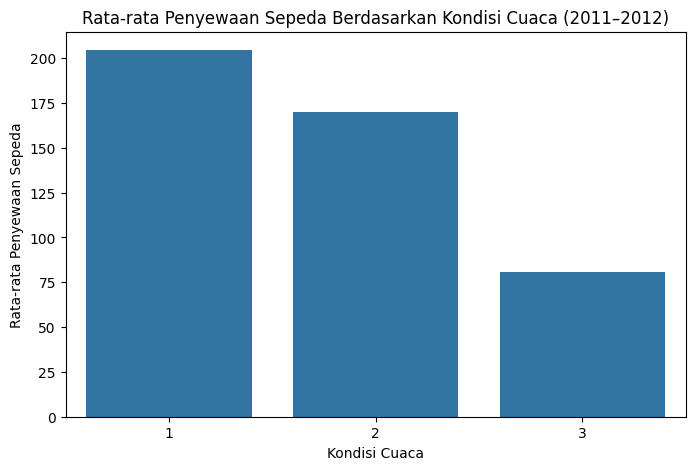

In [32]:
# Rata-rata penyewaan sepeda berdasarkan kondisi cuaca
weather_rentals = day_hour_df.groupby(by="weathersit_day")["cnt_hour"].mean().reset_index()

plt.figure(figsize=(8,5))
sns.barplot(x="weathersit_day", y="cnt_hour", data=weather_rentals)

plt.title("Rata-rata Penyewaan Sepeda Berdasarkan Kondisi Cuaca (2011–2012)")
plt.xlabel("Kondisi Cuaca")
plt.ylabel("Rata-rata Penyewaan Sepeda")
plt.show()

### Pertanyaan 2:

Bagaimana perbedaan jumlah penyewaan sepeda antara hari kerja dan hari libur pada sistem bike sharing selama periode 2011–2012?

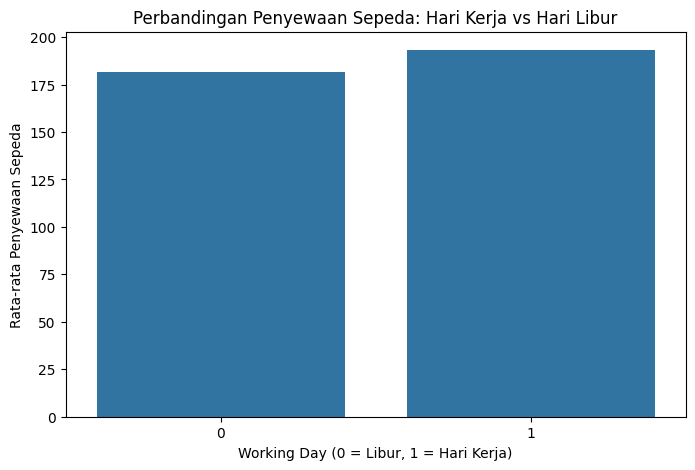

In [33]:
# Rata-rata penyewaan sepeda berdasarkan hari kerja
workingday_rentals = day_hour_df.groupby(by="workingday_day")["cnt_hour"].mean().reset_index()

plt.figure(figsize=(8,5))
sns.barplot(x="workingday_day", y="cnt_hour", data=workingday_rentals)

plt.title("Perbandingan Penyewaan Sepeda: Hari Kerja vs Hari Libur")
plt.xlabel("Working Day (0 = Libur, 1 = Hari Kerja)")
plt.ylabel("Rata-rata Penyewaan Sepeda")
plt.show()

### Pertanyaan 3

Pada jam berapa aktivitas penyewaan sepeda paling tinggi dalam satu hari berdasarkan data tahun 2011–2012?

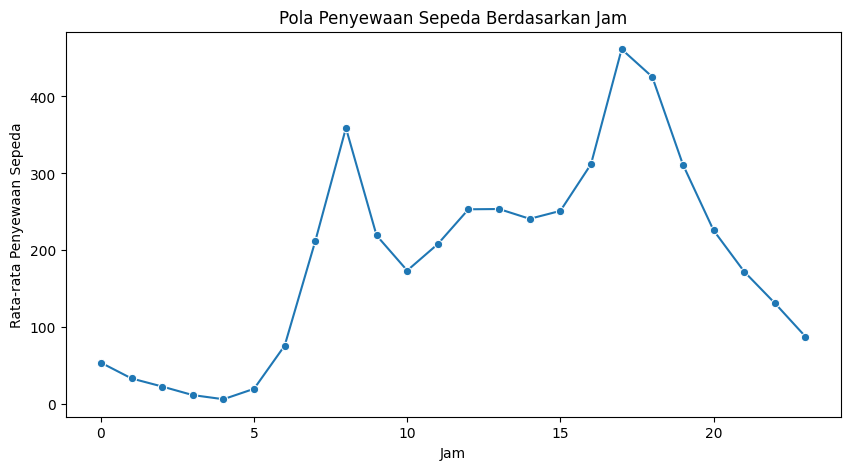

In [34]:
# Rata-rata penyewaan sepeda berdasarkan jam
hour_rentals = day_hour_df.groupby(by="hr")["cnt_hour"].mean().reset_index()

plt.figure(figsize=(10,5))
sns.lineplot(x="hr", y="cnt_hour", data=hour_rentals, marker="o")

plt.title("Pola Penyewaan Sepeda Berdasarkan Jam")
plt.xlabel("Jam")
plt.ylabel("Rata-rata Penyewaan Sepeda")
plt.show()

**Insight:**
- Kondisi cuaca memiliki pengaruh yang cukup signifikan terhadap jumlah penyewaan sepeda. Penyewaan sepeda paling tinggi terjadi pada kondisi cuaca cerah, sedangkan jumlah penyewaan cenderung menurun ketika kondisi cuaca menjadi lebih buruk seperti berkabut atau hujan ringan.

- Jika dilihat dari jenis hari, rata-rata penyewaan sepeda lebih tinggi pada hari kerja dibandingkan hari libur. Hal ini menunjukkan bahwa layanan bike sharing kemungkinan besar digunakan sebagai sarana transportasi harian untuk aktivitas seperti pergi bekerja atau sekolah.

- Berdasarkan pola waktu dalam satu hari, aktivitas penyewaan sepeda paling tinggi terjadi pada jam 17.00–18.00, diikuti oleh sekitar jam 08.00. Pola ini menunjukkan adanya hubungan dengan waktu mobilitas masyarakat, seperti jam berangkat dan pulang kerja.

- Secara keseluruhan, faktor cuaca, jenis hari, dan waktu dalam sehari memiliki pengaruh terhadap pola penggunaan sistem bike sharing selama periode 2011–2012.

## Analisis Lanjutan (Opsional)

In [35]:
# Mengelompokkan tingkat penggunaan sepeda
day_df["rental_category"] = pd.cut(
    day_df["cnt"],
    bins=3,
    labels=["Low Usage", "Medium Usage", "High Usage"]
)

day_df[["dteday","cnt","rental_category"]].head()

,dteday,cnt,rental_category
0,2011-01-01,985,Low Usage
1,2011-01-02,801,Low Usage
2,2011-01-03,1349,Low Usage
3,2011-01-04,1562,Low Usage
4,2011-01-05,1600,Low Usage


In [36]:
# Melihat distribusi Kategori
day_df["rental_category"].value_counts()

,count
rental_category,
Medium Usage,370
High Usage,194
Low Usage,167


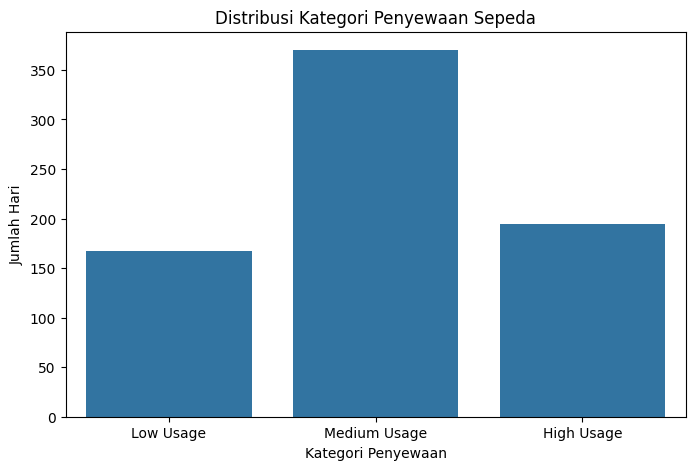

In [37]:
# Visualisasi Distribusi
plt.figure(figsize=(8,5))
sns.countplot(x="rental_category", data=day_df)

plt.title("Distribusi Kategori Penyewaan Sepeda")
plt.xlabel("Kategori Penyewaan")
plt.ylabel("Jumlah Hari")

plt.show()

**Insight:**

- Berdasarkan hasil pengelompokan jumlah penyewaan sepeda, data dapat dikategorikan menjadi tiga kelompok yaitu Low Usage, Medium Usage, dan High Usage.

- Sebagian besar hari berada pada kategori Medium Usage, yang menunjukkan bahwa tingkat penggunaan sepeda relatif stabil sepanjang periode pengamatan.

- Kategori High Usage menunjukkan hari-hari dengan aktivitas penyewaan sepeda yang sangat tinggi, yang kemungkinan dipengaruhi oleh kondisi cuaca yang baik atau musim tertentu.

## Conclusion

- Conclution pertanyaan 1

Berdasarkan hasil analisis, kondisi cuaca memiliki pengaruh terhadap jumlah penyewaan sepeda. Penyewaan sepeda paling tinggi terjadi pada kondisi cuaca cerah, sedangkan jumlah penyewaan sepeda menurun ketika kondisi cuaca menjadi lebih buruk seperti berkabut atau hujan ringan. Hal ini menunjukkan bahwa pengguna lebih cenderung menggunakan layanan bike sharing ketika kondisi cuaca mendukung aktivitas luar ruangan.

- Conclution pertanyaan 2

Hasil analisis menunjukkan bahwa jumlah penyewaan sepeda lebih tinggi pada hari kerja dibandingkan hari libur. Hal ini menunjukkan bahwa layanan bike sharing kemungkinan besar digunakan sebagai sarana transportasi harian, seperti untuk pergi bekerja atau melakukan aktivitas rutin lainnya.

- Conclution pertanyaan 3

Berdasarkan pola penyewaan sepeda dalam satu hari, aktivitas penyewaan sepeda paling tinggi terjadi pada sekitar jam 17.00–18.00, diikuti oleh peningkatan pada sekitar jam 08.00. Pola ini menunjukkan bahwa sepeda banyak digunakan sebagai sarana transportasi pada waktu mobilitas masyarakat yang tinggi, seperti saat berangkat dan pulang kerja.

In [38]:
 pip freeze requirements.txt

absl-py==1.4.0
accelerate==1.13.0
access==1.1.10.post3
affine==2.4.0
aiofiles==24.1.0
aiohappyeyeballs==2.6.1
aiohttp==3.13.3
aiosignal==1.4.0
aiosqlite==0.22.1
alabaster==1.0.0
albucore==0.0.24
albumentations==2.0.8
ale-py==0.11.2
alembic==1.18.4
altair==5.5.0
annotated-doc==0.0.4
annotated-types==0.7.0
antlr4-python3-runtime==4.9.3
anyio==4.12.1
anywidget==0.9.21
apsw==3.51.2.0
apswutils==0.1.2
argon2-cffi==25.1.0
argon2-cffi-bindings==25.1.0
array_record==0.8.3
arrow==1.4.0
arviz==0.22.0
astropy==7.2.0
astropy-iers-data==0.2026.3.2.0.47.4
astunparse==1.6.3
atpublic==5.1
attrs==25.4.0
audioread==3.1.0
Authlib==1.6.9
autograd==1.8.0
babel==2.18.0
backcall==0.2.0
beartype==0.22.9
beautifulsoup4==4.13.5
betterproto==2.0.0b6
bigframes==2.37.0
bigquery-magics==0.10.3
bleach==6.3.0
blinker==1.9.0
blis==1.3.3
blobfile==3.2.0
blosc2==4.1.2
bokeh==3.8.2
Bottleneck==1.4.2
bqplot==0.12.45
branca==0.8.2
brotli==1.2.0
CacheControl==0.14.4
cachetools==6.2.6
catalogue==2.0.10
certifi==2026.2.25
cff

In [39]:
# Gabungkan dataset day dan hour
main_df = pd.merge(
    hour_df,
    day_df,
    on="dteday",
    how="left",
    suffixes=("_hour", "_day")
)

# Simpan untuk dashboard
main_df.to_csv("main_data.csv", index=False)